# Tugas Besar IF3270 Pembelajaran Mesin
## Feedforward Neural Network

**Nama Anggota:**
- 13523135 - Ahmad Syafiq
- 13523152 — Muhammad Kinan Arkansyaddad
- 13523162 — Fachriza Ahmad Setiyono

**Kelas:** 3

---

## 0. Import Libraries & Load Data

In [1]:
!pip install -r ../requirements.txt

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score
from models.nn import FFNN

# tambahkan import lainnya sesuai kebutuhan

RANDOM_STATE = 42

In [3]:
# Load dataset
file_path = '../data/datasetml_2026.csv'

train_df = pd.read_csv(file_path)

print("Train shape:", train_df.shape)

Train shape: (10000, 12)


---
## 1. Exploratory Data Analysis (EDA)

> **Tujuan:** Memahami data secara mendalam sebelum preprocessing dan modeling.
> **Requirement:** Minimal **3 visualisasi** dengan **3 pertanyaan** (1 per visualisasi).

### 1.1 Gambaran Umum Dataset

In [4]:
train_df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 937.6+ KB


In [6]:
TARGET_COL = 'placement_status'
NUM_COLS = ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']
ORDINAL_COLS = ['college_tier', 'university_ranking_band']
CATEGORICAL_COLS = ['country', 'specialization', 'industry']

In [7]:
train_df.describe(include='all')

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
count,10000.000000,10000.000000,10000,10000,10000,10000.00000,10000.000000,10000.000000,10000,10000,10000.000000,10000
unique,NaN,NaN,3,5,3,NaN,NaN,NaN,5,6,NaN,2
top,NaN,NaN,Tier 2,Germany,300+,NaN,NaN,NaN,Data Science,Consulting,NaN,Placed
freq,NaN,NaN,3993,2057,4075,NaN,NaN,NaN,2036,1739,NaN,6153
mean,6.998290,1.248100,NaN,NaN,NaN,1.49930,69.877531,65.158600,NaN,NaN,5.021436,NaN
std,0.802606,1.149904,NaN,NaN,NaN,1.20289,14.700532,14.740446,NaN,NaN,1.505975,NaN
min,4.000000,0.000000,NaN,NaN,NaN,0.00000,30.000000,30.000000,NaN,NaN,1.000000,NaN
25%,6.461928,0.000000,NaN,NaN,NaN,1.00000,59.880399,55.112244,NaN,NaN,4.012656,NaN
50%,6.997924,1.000000,NaN,NaN,NaN,1.00000,70.097368,65.006484,NaN,NaN,5.017335,NaN
75%,7.536865,2.000000,NaN,NaN,NaN,2.00000,80.213934,75.277248,NaN,NaN,6.031400,NaN


In [8]:
# Cek missing values
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)


In [9]:
# Distribusi kelas target
print(train_df[TARGET_COL].value_counts())

placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64


### 1.2 Visualisasi 1 — Distribusi Kelas

*Pertanyaan:* Apakah proporsi kelas pada dataset seimbang atau imbalanced?

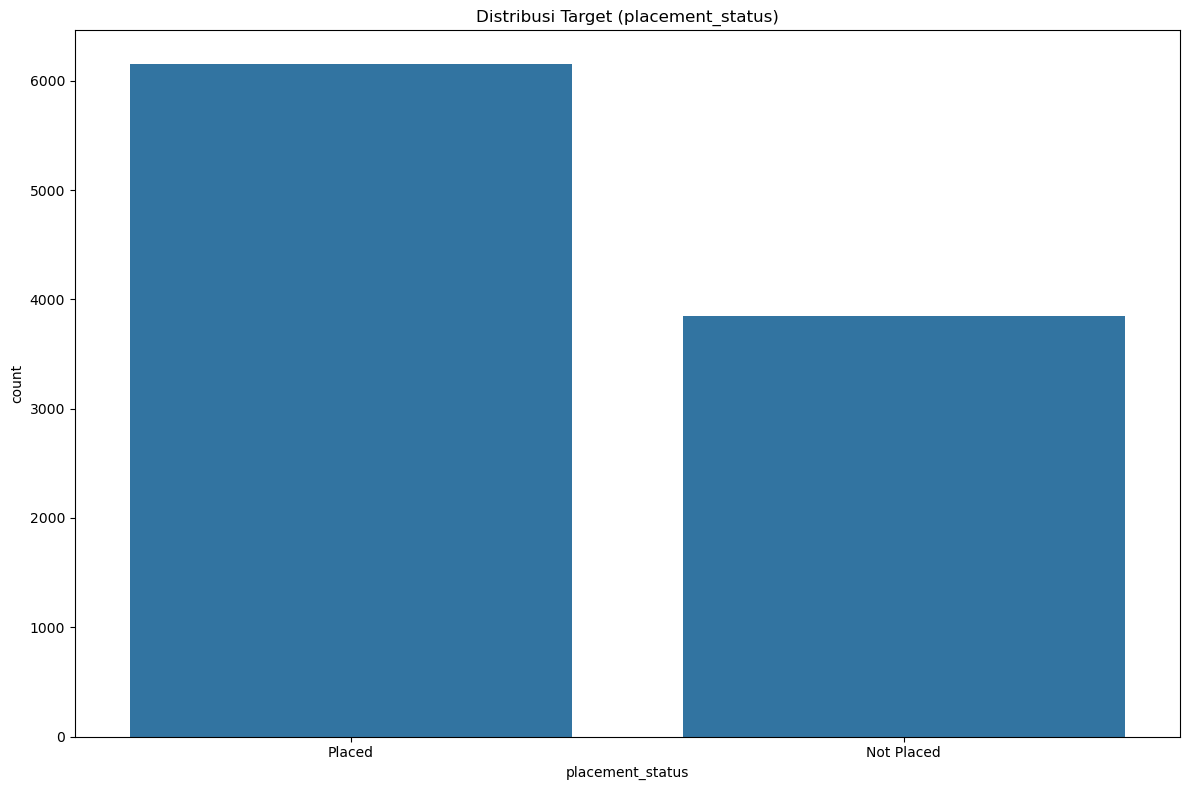

In [10]:
fig, axes = plt.subplots(1, 1, figsize=(12, 8))

sns.countplot(data=train_df, x=TARGET_COL, ax=axes)
axes.set_title('Distribusi Target (placement_status)')

plt.tight_layout()
plt.show()

**Analisis:** a

### 1.3 Visualisasi 2 — *Outlier* dataset

*Pertanyaan:* Apakah ada *outlier* pada target dataset terhadap fitur dataset?

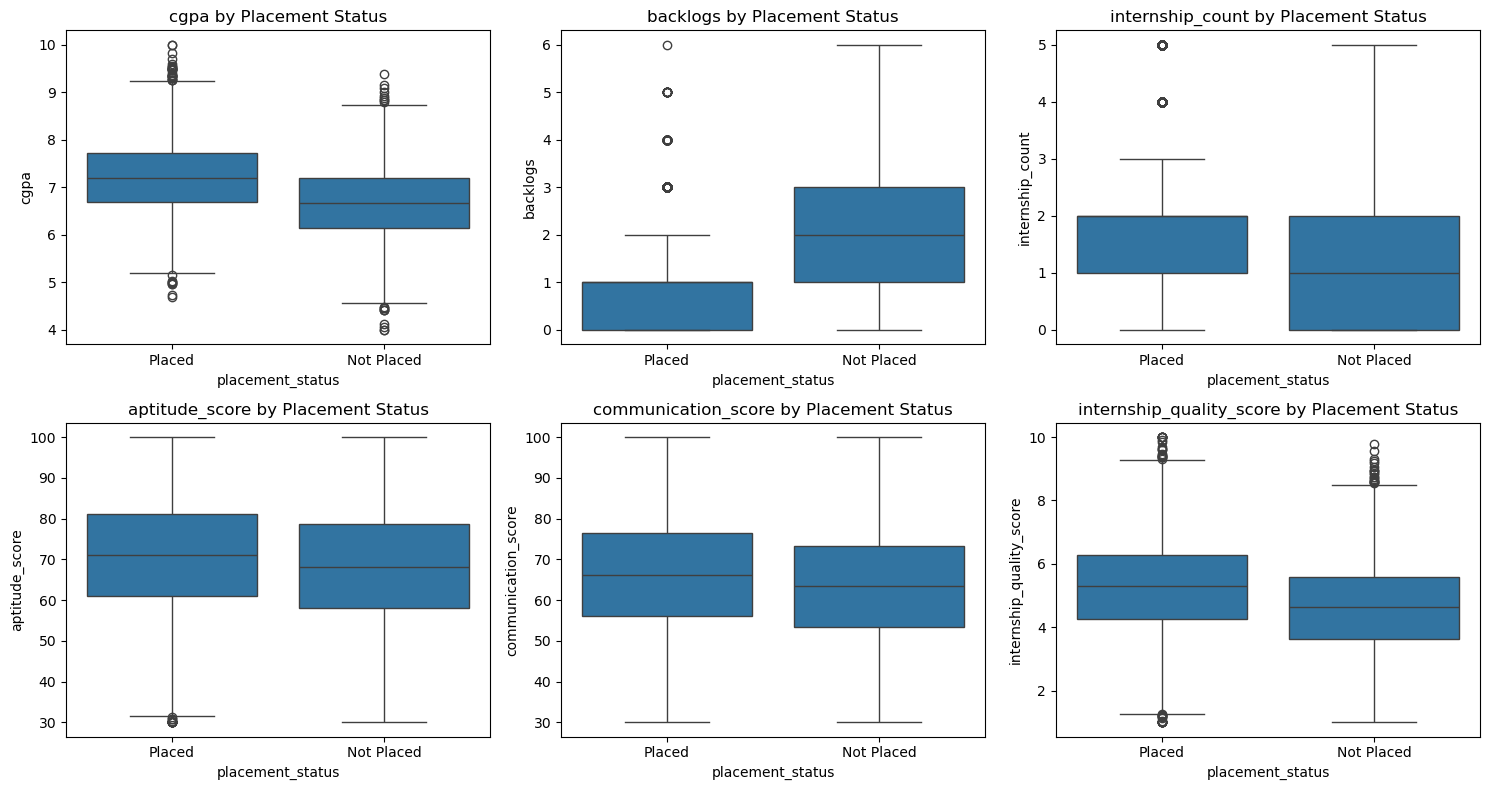

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), NUM_COLS):
    sns.boxplot(data=train_df, x=TARGET_COL, y=col, ax=ax)
    ax.set_title(f'{col} by Placement Status')
plt.tight_layout()
plt.show()

**Analisis:** Dari diagram *boxplot* .

### 1.4 Visualisasi 2 — Hubungan Kolom Kategorikal dengan Kelas Target

*Pertanyaan:* Bagaimana korelasi antara kelas target dengan kolom kategorikal?

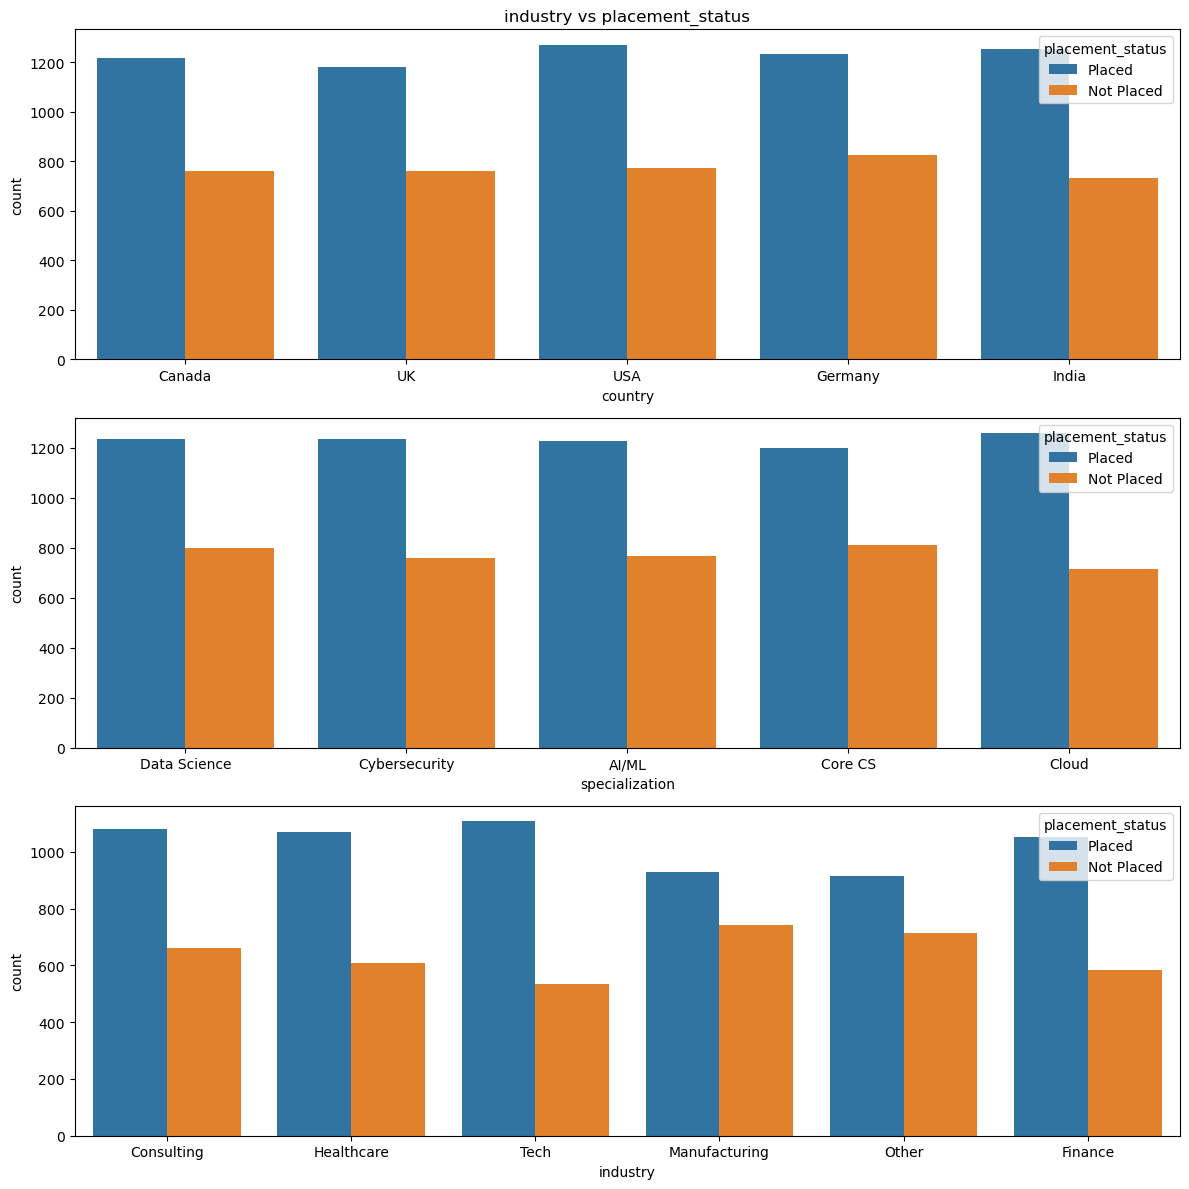

In [12]:
fig, axes = plt.subplots(len(CATEGORICAL_COLS), 1, figsize=(12, 12))


for i in range(len(CATEGORICAL_COLS)):
    sns.countplot(data=train_df, x=CATEGORICAL_COLS[i], hue=TARGET_COL, ax=axes[i])
    axes[0].set_title(f'{CATEGORICAL_COLS[i]} vs {TARGET_COL}')

plt.tight_layout()
plt.show()

**Analisis:**
Dari grafik tersebut, terlihat 

### 1.5 Heatmap Korelasi antar Fitur Numerik

*Pertanyaan:* Bagaimana korelasi antara fitur numerik dataset?

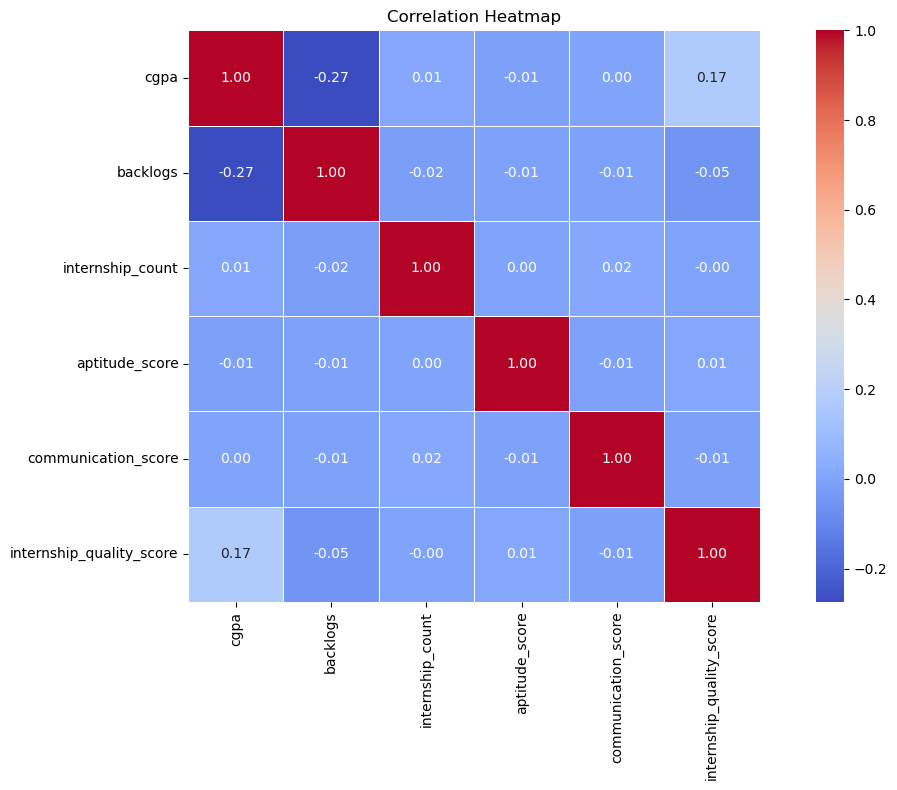

In [13]:
plt.figure(figsize=(12, 8))
corr_matrix = train_df[NUM_COLS].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Analisis:** *Heatmap* menunjukkan

---
## 2. Data Cleaning and Preprocessing

> **Tujuan:** Menyiapkan data untuk training model.
> **Requirement:** Sertakan **penjelasan** untuk setiap langkah.

> ⚠️ **Ingat:** Fit transformer **hanya pada training data**, lalu transform train dan test secara terpisah untuk menghindari data leakage.

In [14]:
# TARGET_COL, NUM_COLS, ORDINAL_COLS, CATEGORICAL_COLS sudah terdefinisi

print("Categorical:", CATEGORICAL_COLS)
print("Numerical:  ", NUM_COLS)

X = train_df.drop(TARGET_COL, axis=1)
y = train_df[TARGET_COL]


Categorical: ['country', 'specialization', 'industry']
Numerical:   ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']


### 2.1 Pisahkan Fitur (X) dan Target (y)

In [15]:
X = train_df.drop(columns=[TARGET_COL])
y = train_df[TARGET_COL]

### 2.2 Handling Outliers

**Penjelasan:** *[Apakah Anda menangani outlier? Metode dan alasannya?]*

In [16]:
# for col in NUM_COLS:
#     Q1 = train[col].quantile(0.25)
#     Q3 = train[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     # Menghitung jumlah yang terdampak (opsional untuk log)
#     outliers = ((train[col] < lower_bound) | (train[col] > upper_bound)).sum()
#     print(f" - {col}: {outliers} outlier dideteksi")

#     # Clipping data train dan test menggunakan bound dari train
#     train[col] = train[col].clip(lower=lower_bound, upper=upper_bound)
#     test[col]  = test[col].clip(lower=lower_bound, upper=upper_bound)

### 2.3 Preprocessing Pipeline

In [17]:
label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)

college_tiers = ['Tier 3', 'Tier 2', 'Tier 1']
ranking_bands = ['300+', '100-300', 'Top 100']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[college_tiers, ranking_bands]))
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 7. Combine all steps into a ColumnTransformer Preprocessor
preprocessor = ColumnTransformer([
    ('num', num_pipeline, NUM_COLS),
    ('ord', ordinal_pipeline, ORDINAL_COLS),
    ('cat', nominal_pipeline, CATEGORICAL_COLS)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, NUM_COLS),
        ('ord', ordinal_pipeline, ORDINAL_COLS),
        ('cat', nominal_pipeline, CATEGORICAL_COLS)
    ])

X_preprocessed = preprocessor.fit_transform(X)

### 2.4 Feature Scaling

**Penjelasan:** *[Apakah perlu scaling? Untuk model apa? Metode yang dipilih?]*

### 2.5 (Opsional) Feature Engineering / Selection

### 2.6 Train-Validation Split

In [18]:
# Pembagian Dataset (Train: 70%, Val: 15%, Test: 15%)
X_temp, X_test, y_temp, y_test = train_test_split(X_preprocessed, y_encoded, test_size=0.15, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=RANDOM_STATE)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)
print("X_test:  ", X_test.shape,   "| y_val:  ", y_test.shape)

X_train: (6999, 24) | y_train: (6999,)
X_val:   (1501, 24) | y_val:   (1501,)
X_test:   (1500, 24) | y_val:   (1500,)


### 2.7 Reshape target ke bentuk matriks (N, 1) dan ubah ke float64 untuk model custom FFNN

In [19]:
y_train = y_train.reshape(-1, 1).astype(np.float64)
y_val = y_val.reshape(-1, 1).astype(np.float64)
y_test = y_test.reshape(-1, 1).astype(np.float64)

X_train = X_train.astype(np.float64)
X_val = X_val.astype(np.float64)
X_test = X_test.astype(np.float64)
nin = X_train.shape[1] # Ukuran input layer (banyak fitur)

print("Dimensi X_train:", X_train.shape)
print("Dimensi y_train:", y_train.shape)

Dimensi X_train: (6999, 24)
Dimensi y_train: (6999, 1)


---
## 3. Pengujian

> **Metrik utama:** Macro F1-Score

In [23]:
from sklearn.metrics import accuracy_score


def plot_loss_curve(history, title="Training and Validation Loss"):
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    if len(history['val_loss']) > 0:
        plt.plot(history['val_loss'], label='Val Loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss (BCE)')
    plt.legend()
    plt.grid(True)
    plt.show()

def evaluate_model(model, X, y, threshold=0.5):
    preds = model.predict(X)
    preds_class = (preds >= threshold).astype(int)
    print(f"Accuracy: {accuracy_score(y, preds_class):.4f}")
    print(classification_report(y, preds_class, target_names=['Not Placed (0)', 'Placed (1)'], zero_division=0))

### 3.1 Hyperparameter

#### 3.1.1 Pengaruh depth (banyak layer) dan width (banyak neuron per layer)

 EKSPERIMEN VARIASI WIDTH (DEPTH TETAP) 
Training Model Width: 8 neurons
Epoch 1/30
219/219 [------------------------------] - loss: 1.5895 - val_loss: 1.1912
Epoch 2/30
219/219 [------------------------------] - loss: 1.0458 - val_loss: 0.9535
Epoch 3/30
219/219 [------------------------------] - loss: 0.8863 - val_loss: 0.8484
Epoch 4/30
219/219 [------------------------------] - loss: 0.8072 - val_loss: 0.7964
Epoch 5/30
219/219 [------------------------------] - loss: 0.7627 - val_loss: 0.7587
Epoch 6/30
219/219 [------------------------------] - loss: 0.7358 - val_loss: 0.7383
Epoch 7/30
219/219 [------------------------------] - loss: 0.7170 - val_loss: 0.7216
Epoch 8/30
219/219 [------------------------------] - loss: 0.7035 - val_loss: 0.7092
Epoch 9/30
219/219 [------------------------------] - loss: 0.6930 - val_loss: 0.7046
Epoch 10/30
219/219 [------------------------------] - loss: 0.6851 - val_loss: 0.6931
Epoch 11/30
219/219 [------------------------------] - loss: 0.678

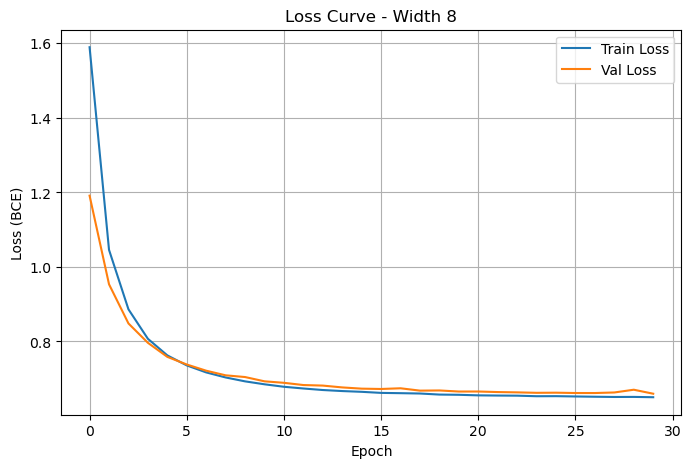


[Evaluasi Validation] Model Width 8:
Accuracy: 0.6129
                precision    recall  f1-score   support

Not Placed (0)       0.55      0.13      0.21       594
    Placed (1)       0.62      0.93      0.74       907

      accuracy                           0.61      1501
     macro avg       0.58      0.53      0.47      1501
  weighted avg       0.59      0.61      0.53      1501


[Distribusi] Model Width 8 - Hidden Layer Terakhir


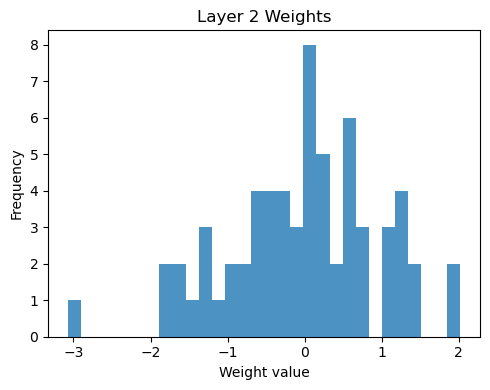

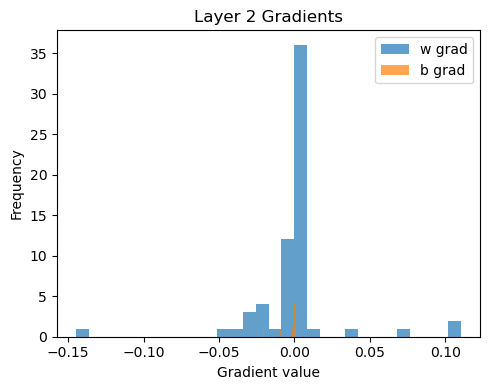

Training Model Width: 16 neurons
Epoch 1/30
219/219 [------------------------------] - loss: 5.0833 - val_loss: 2.1727
Epoch 2/30
219/219 [------------------------------] - loss: 1.7756 - val_loss: 1.4008
Epoch 3/30
219/219 [------------------------------] - loss: 1.2324 - val_loss: 1.3882
Epoch 4/30
219/219 [------------------------------] - loss: 1.0412 - val_loss: 0.8826
Epoch 5/30
219/219 [------------------------------] - loss: 0.8922 - val_loss: 0.8922
Epoch 6/30
219/219 [------------------------------] - loss: 0.8347 - val_loss: 0.8601
Epoch 7/30
219/219 [------------------------------] - loss: 0.8255 - val_loss: 0.7403
Epoch 8/30
219/219 [------------------------------] - loss: 0.7642 - val_loss: 0.7106
Epoch 9/30
219/219 [------------------------------] - loss: 0.7667 - val_loss: 0.6687
Epoch 10/30
219/219 [------------------------------] - loss: 0.7309 - val_loss: 0.7734
Epoch 11/30
219/219 [------------------------------] - loss: 0.7275 - val_loss: 0.8935
Epoch 12/30
219/219

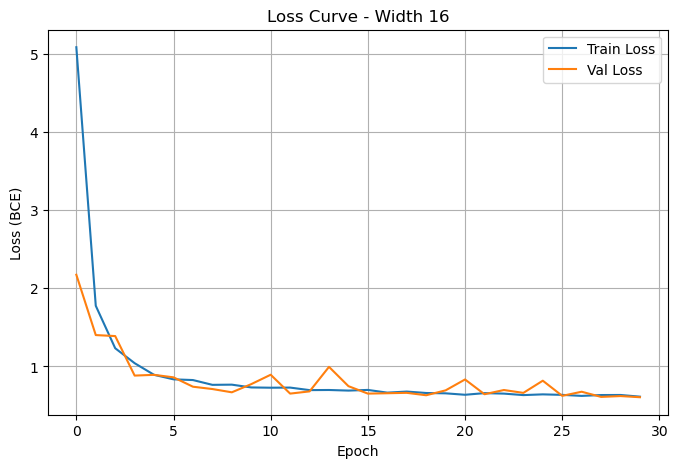


[Evaluasi Validation] Model Width 16:
Accuracy: 0.6676
                precision    recall  f1-score   support

Not Placed (0)       0.59      0.51      0.55       594
    Placed (1)       0.71      0.77      0.74       907

      accuracy                           0.67      1501
     macro avg       0.65      0.64      0.64      1501
  weighted avg       0.66      0.67      0.66      1501


[Distribusi] Model Width 16 - Hidden Layer Terakhir


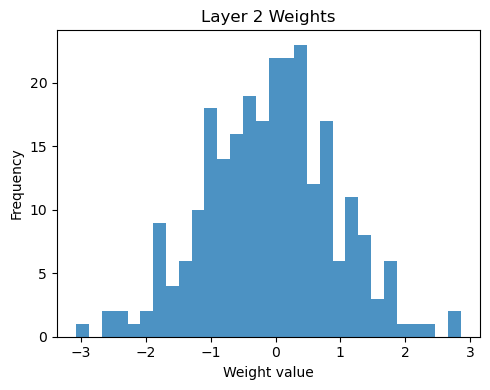

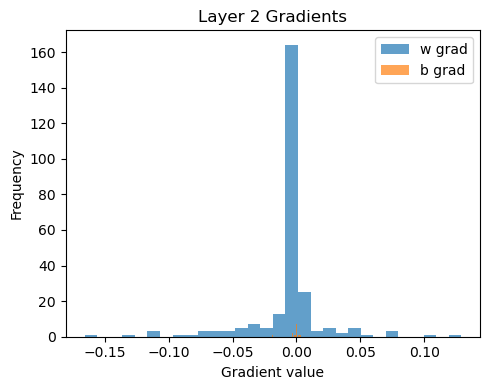

Training Model Width: 32 neurons
Epoch 1/30
219/219 [------------------------------] - loss: 11.8721 - val_loss: 11.2139
Epoch 2/30
219/219 [------------------------------] - loss: 9.5940 - val_loss: 10.4691
Epoch 3/30
219/219 [------------------------------] - loss: 9.0281 - val_loss: 10.0521
Epoch 4/30
219/219 [------------------------------] - loss: 8.6917 - val_loss: 9.8219
Epoch 5/30
219/219 [------------------------------] - loss: 8.3496 - val_loss: 9.2429
Epoch 6/30
219/219 [------------------------------] - loss: 8.0018 - val_loss: 8.9312
Epoch 7/30
219/219 [------------------------------] - loss: 7.6683 - val_loss: 8.6084
Epoch 8/30
219/219 [------------------------------] - loss: 7.3065 - val_loss: 8.0618
Epoch 9/30
219/219 [------------------------------] - loss: 6.9260 - val_loss: 7.5122
Epoch 10/30
219/219 [------------------------------] - loss: 6.5081 - val_loss: 6.8663
Epoch 11/30
219/219 [------------------------------] - loss: 5.9469 - val_loss: 6.2668
Epoch 12/30
219

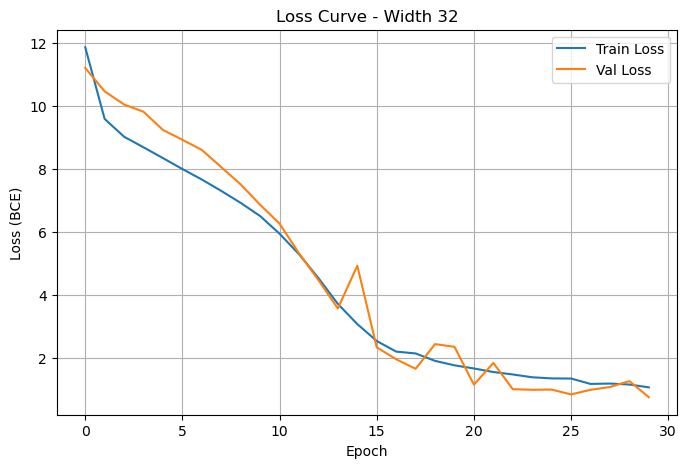


[Evaluasi Validation] Model Width 32:
Accuracy: 0.6696
                precision    recall  f1-score   support

Not Placed (0)       0.56      0.72      0.63       594
    Placed (1)       0.78      0.64      0.70       907

      accuracy                           0.67      1501
     macro avg       0.67      0.68      0.67      1501
  weighted avg       0.69      0.67      0.67      1501


[Distribusi] Model Width 32 - Hidden Layer Terakhir


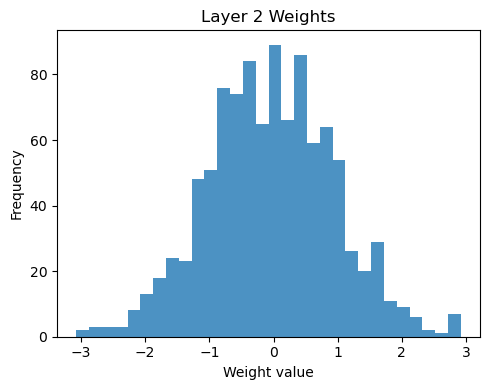

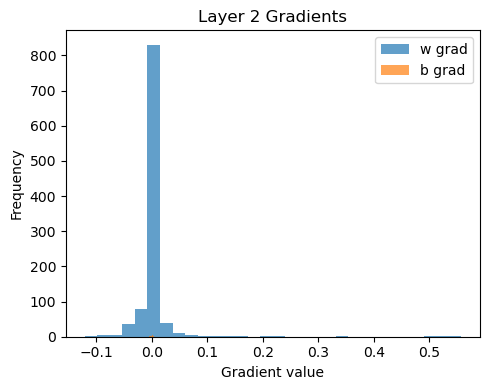

In [26]:
print(" EKSPERIMEN VARIASI WIDTH (DEPTH TETAP) ")

widths = [8, 16, 32]
models_width = {}

for w in widths:
    print(f"Training Model Width: {w} neurons")
    
    config = [nin, w, w, w, 1]
    acts = ['relu', 'relu', 'relu', 'sigmoid']
    
    model_w = FFNN(layers_config=config, activations=acts, loss_function='bce', random_state=RANDOM_STATE)
    history_w = model_w.fit(X_train, y_train, X_val, y_val, solver='sgd', lr=0.001, epochs=30, batch_size=32, verbose=1)
    
    models_width[w] = model_w
    plot_loss_curve(history_w, title=f"Loss Curve - Width {w}")
    print(f"\n[Evaluasi Validation] Model Width {w}:")
    evaluate_model(model_w, X_val, y_val)
    
    print(f"\n[Distribusi] Model Width {w} - Hidden Layer Terakhir")
    model_w.plot_weights_distribution(layer_indices=[2])
    model_w.plot_gradients_distribution(layer_indices=[2])

 EKSPERIMEN VARIASI DEPTH (WIDTH TETAP) 

Training Model Depth: 1 Hidden
Epoch 1/30
219/219 [------------------------------] - loss: 3.2065 - val_loss: 2.5837
Epoch 2/30
219/219 [------------------------------] - loss: 2.4132 - val_loss: 2.1061
Epoch 3/30
219/219 [------------------------------] - loss: 2.0049 - val_loss: 1.8026
Epoch 4/30
219/219 [------------------------------] - loss: 1.7358 - val_loss: 1.6052
Epoch 5/30
219/219 [------------------------------] - loss: 1.5551 - val_loss: 1.4711
Epoch 6/30
219/219 [------------------------------] - loss: 1.4288 - val_loss: 1.3784
Epoch 7/30
219/219 [------------------------------] - loss: 1.3380 - val_loss: 1.3081
Epoch 8/30
219/219 [------------------------------] - loss: 1.2690 - val_loss: 1.2521
Epoch 9/30
219/219 [------------------------------] - loss: 1.2148 - val_loss: 1.2064
Epoch 10/30
219/219 [------------------------------] - loss: 1.1689 - val_loss: 1.1682
Epoch 11/30
219/219 [------------------------------] - loss: 1.130

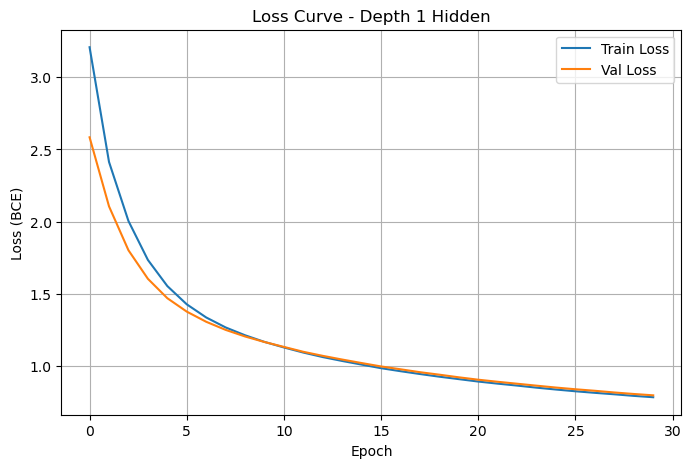


[Evaluasi Validation] Model Depth 1 Hidden:
Accuracy: 0.6795
                precision    recall  f1-score   support

Not Placed (0)       0.60      0.56      0.58       594
    Placed (1)       0.72      0.76      0.74       907

      accuracy                           0.68      1501
     macro avg       0.66      0.66      0.66      1501
  weighted avg       0.68      0.68      0.68      1501


[Distribusi] Model Depth 1 Hidden - Hidden Layer 1


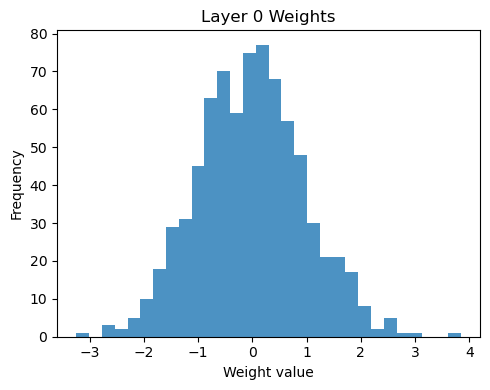

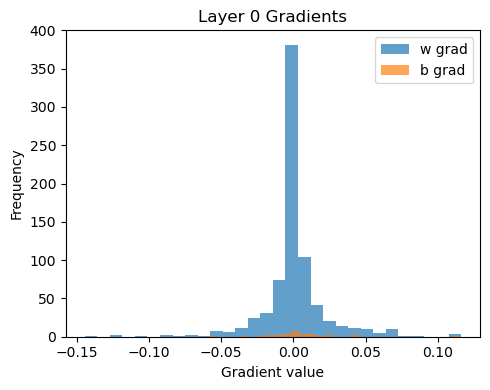


Training Model Depth: 2 Hidden
Epoch 1/30
219/219 [------------------------------] - loss: 7.3569 - val_loss: 5.7065
Epoch 2/30
219/219 [------------------------------] - loss: 4.6926 - val_loss: 4.4264
Epoch 3/30
219/219 [------------------------------] - loss: 3.7551 - val_loss: 3.7650
Epoch 4/30
219/219 [------------------------------] - loss: 3.2223 - val_loss: 3.2413
Epoch 5/30
219/219 [------------------------------] - loss: 2.8404 - val_loss: 2.9079
Epoch 6/30
219/219 [------------------------------] - loss: 2.5584 - val_loss: 2.6272
Epoch 7/30
219/219 [------------------------------] - loss: 2.3267 - val_loss: 2.4292
Epoch 8/30
219/219 [------------------------------] - loss: 2.1403 - val_loss: 2.2452
Epoch 9/30
219/219 [------------------------------] - loss: 1.9819 - val_loss: 2.0857
Epoch 10/30
219/219 [------------------------------] - loss: 1.8457 - val_loss: 1.9439
Epoch 11/30
219/219 [------------------------------] - loss: 1.7301 - val_loss: 1.8581
Epoch 12/30
219/219 

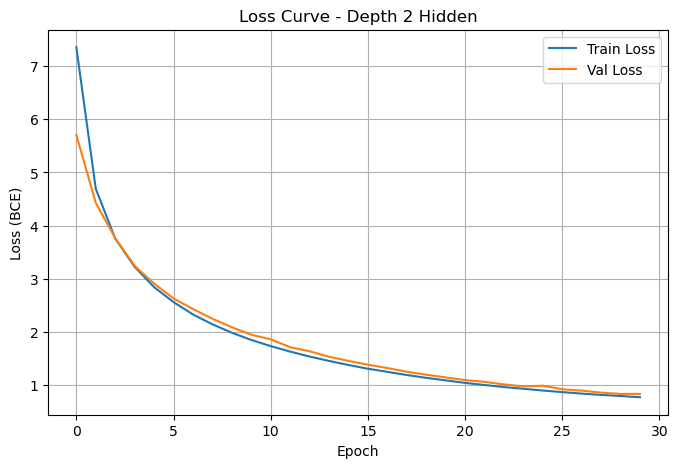


[Evaluasi Validation] Model Depth 2 Hidden:
Accuracy: 0.6875
                precision    recall  f1-score   support

Not Placed (0)       0.63      0.51      0.56       594
    Placed (1)       0.71      0.81      0.76       907

      accuracy                           0.69      1501
     macro avg       0.67      0.66      0.66      1501
  weighted avg       0.68      0.69      0.68      1501


[Distribusi] Model Depth 2 Hidden - Hidden Layer 1


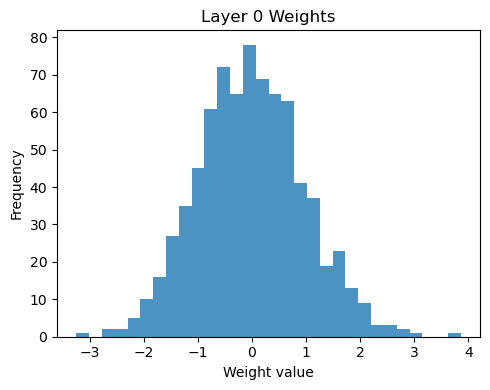

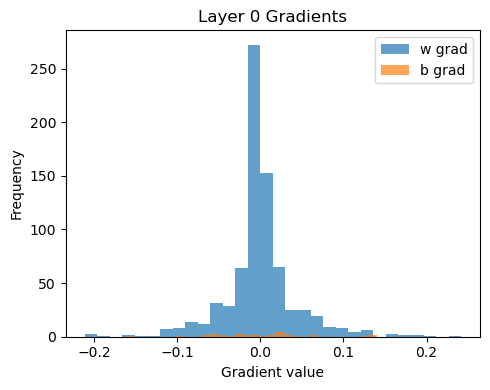


Training Model Depth: 3 Hidden
Epoch 1/30
219/219 [------------------------------] - loss: 11.8721 - val_loss: 11.2139
Epoch 2/30
219/219 [------------------------------] - loss: 9.5940 - val_loss: 10.4691
Epoch 3/30
219/219 [------------------------------] - loss: 9.0281 - val_loss: 10.0521
Epoch 4/30
219/219 [------------------------------] - loss: 8.6917 - val_loss: 9.8219
Epoch 5/30
219/219 [------------------------------] - loss: 8.3496 - val_loss: 9.2429
Epoch 6/30
219/219 [------------------------------] - loss: 8.0018 - val_loss: 8.9312
Epoch 7/30
219/219 [------------------------------] - loss: 7.6683 - val_loss: 8.6084
Epoch 8/30
219/219 [------------------------------] - loss: 7.3065 - val_loss: 8.0618
Epoch 9/30
219/219 [------------------------------] - loss: 6.9260 - val_loss: 7.5122
Epoch 10/30
219/219 [------------------------------] - loss: 6.5081 - val_loss: 6.8663
Epoch 11/30
219/219 [------------------------------] - loss: 5.9469 - val_loss: 6.2668
Epoch 12/30
219/

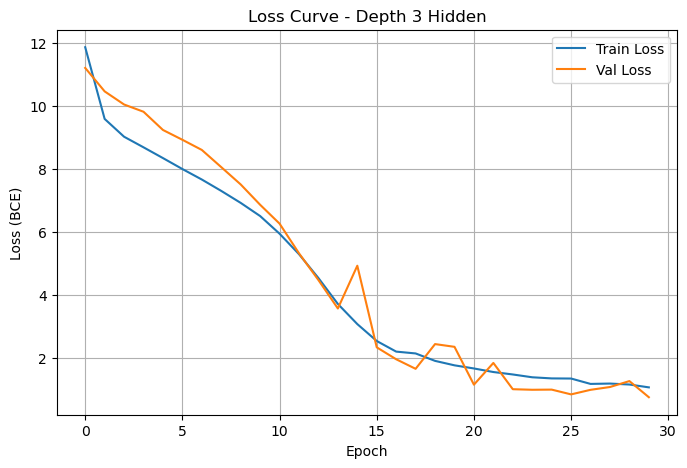


[Evaluasi Validation] Model Depth 3 Hidden:
Accuracy: 0.6696
                precision    recall  f1-score   support

Not Placed (0)       0.56      0.72      0.63       594
    Placed (1)       0.78      0.64      0.70       907

      accuracy                           0.67      1501
     macro avg       0.67      0.68      0.67      1501
  weighted avg       0.69      0.67      0.67      1501


[Distribusi] Model Depth 3 Hidden - Hidden Layer 1


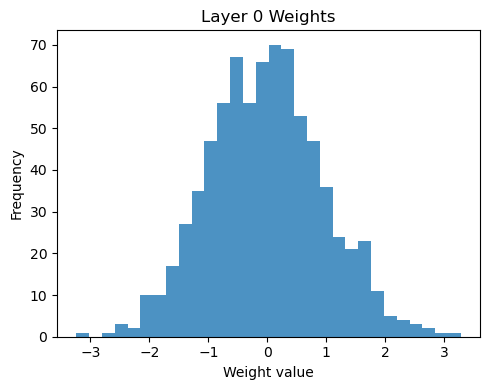

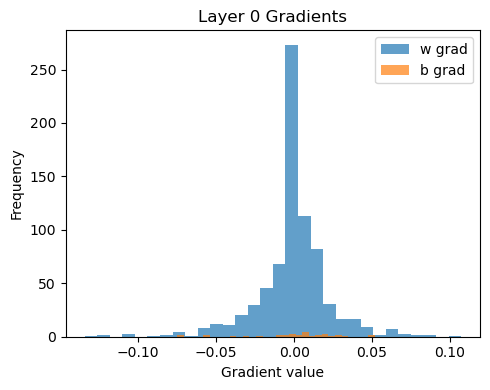

In [27]:
print(" EKSPERIMEN VARIASI DEPTH (WIDTH TETAP) ")

depths_configs = {
    "1 Hidden": ([nin, 32, 1], ['relu', 'sigmoid']),
    "2 Hidden": ([nin, 32, 32, 1], ['relu', 'relu', 'sigmoid']),
    "3 Hidden": ([nin, 32, 32, 32, 1], ['relu', 'relu', 'relu', 'sigmoid'])
}
models_depth = {}

for name, (config, acts) in depths_configs.items():
    print(f"\nTraining Model Depth: {name}")
    
    model_d = FFNN(layers_config=config, activations=acts, loss_function='bce', random_state=RANDOM_STATE)
    history_d = model_d.fit(X_train, y_train, X_val, y_val, solver='sgd', lr=0.001, epochs=30, batch_size=32, verbose=1)
    
    models_depth[name] = model_d
    plot_loss_curve(history_d, title=f"Loss Curve - Depth {name}")
    print(f"\n[Evaluasi Validation] Model Depth {name}:")
    evaluate_model(model_d, X_val, y_val)
    
    print(f"\n[Distribusi] Model Depth {name} - Hidden Layer 1")
    model_d.plot_weights_distribution(layer_indices=[0])
    model_d.plot_gradients_distribution(layer_indices=[0])

#### 3.1.2 Pengaruh fungsi aktivasi hidden layer.


Training Aktivasi Layer Uji: linear
Epoch 1/30
219/219 [------------------------------] - loss: 9.61151 - val_loss: 4.7817
Epoch 2/30
219/219 [------------------------------] - loss: 3.2440 - val_loss: 2.4762
Epoch 3/30
219/219 [------------------------------] - loss: 1.9270 - val_loss: 2.0987
Epoch 4/30
219/219 [------------------------------] - loss: 1.4520 - val_loss: 1.4186
Epoch 5/30
219/219 [------------------------------] - loss: 1.1970 - val_loss: 1.4402
Epoch 6/30
219/219 [------------------------------] - loss: 1.0540 - val_loss: 1.2410
Epoch 7/30
219/219 [------------------------------] - loss: 1.0199 - val_loss: 1.2099
Epoch 8/30
219/219 [------------------------------] - loss: 0.8819 - val_loss: 0.9442
Epoch 9/30
219/219 [------------------------------] - loss: 0.8823 - val_loss: 0.7691
Epoch 10/30
219/219 [------------------------------] - loss: 0.7924 - val_loss: 0.7272
Epoch 11/30
219/219 [------------------------------] - loss: 0.7894 - val_loss: 0.7303
Epoch 12/30
21

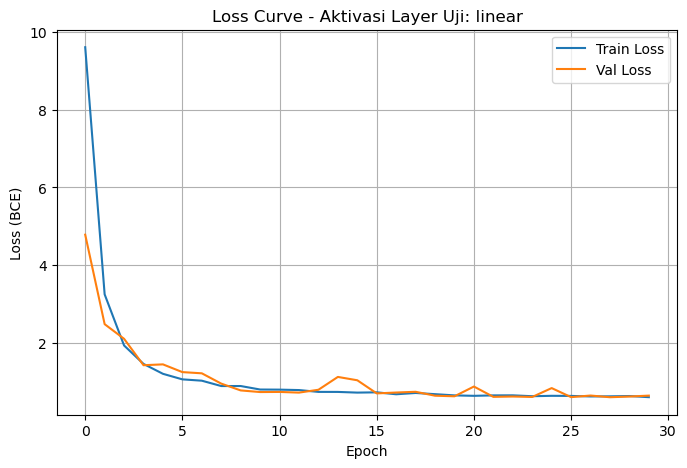


[Evaluasi Validation] Aktivasi linear:
Accuracy: 0.6696
                precision    recall  f1-score   support

Not Placed (0)       0.56      0.77      0.65       594
    Placed (1)       0.80      0.60      0.69       907

      accuracy                           0.67      1501
     macro avg       0.68      0.69      0.67      1501
  weighted avg       0.71      0.67      0.67      1501


[Distribusi] Aktivasi linear - Layer Uji


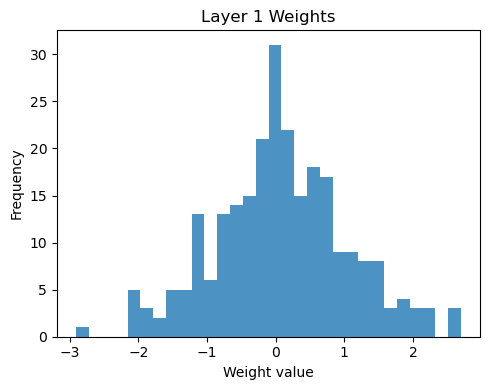

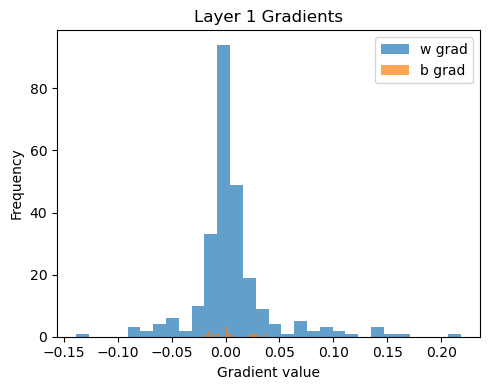


Training Aktivasi Layer Uji: relu
Epoch 1/30
219/219 [------------------------------] - loss: 5.0833 - val_loss: 2.1727
Epoch 2/30
219/219 [------------------------------] - loss: 1.7756 - val_loss: 1.4008
Epoch 3/30
219/219 [------------------------------] - loss: 1.2324 - val_loss: 1.3882
Epoch 4/30
219/219 [------------------------------] - loss: 1.0412 - val_loss: 0.8826
Epoch 5/30
219/219 [------------------------------] - loss: 0.8922 - val_loss: 0.8922
Epoch 6/30
219/219 [------------------------------] - loss: 0.8347 - val_loss: 0.8601
Epoch 7/30
219/219 [------------------------------] - loss: 0.8255 - val_loss: 0.7403
Epoch 8/30
219/219 [------------------------------] - loss: 0.7642 - val_loss: 0.7106
Epoch 9/30
219/219 [------------------------------] - loss: 0.7667 - val_loss: 0.6687
Epoch 10/30
219/219 [------------------------------] - loss: 0.7309 - val_loss: 0.7734
Epoch 11/30
219/219 [------------------------------] - loss: 0.7275 - val_loss: 0.8935
Epoch 12/30
219/2

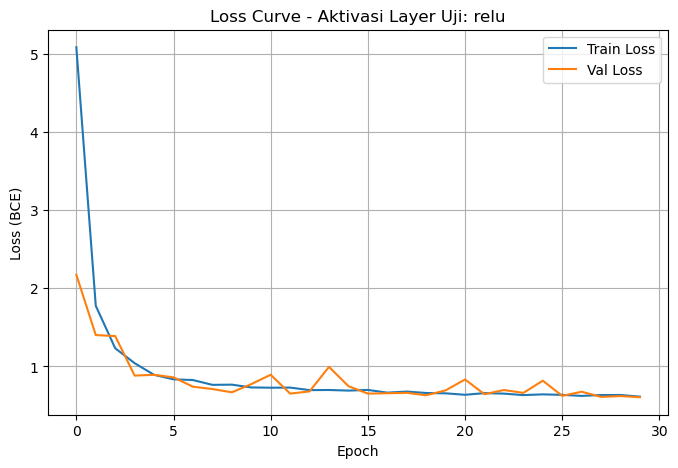


[Evaluasi Validation] Aktivasi relu:
Accuracy: 0.6676
                precision    recall  f1-score   support

Not Placed (0)       0.59      0.51      0.55       594
    Placed (1)       0.71      0.77      0.74       907

      accuracy                           0.67      1501
     macro avg       0.65      0.64      0.64      1501
  weighted avg       0.66      0.67      0.66      1501


[Distribusi] Aktivasi relu - Layer Uji


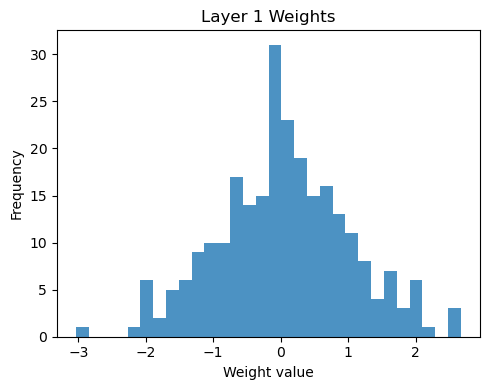

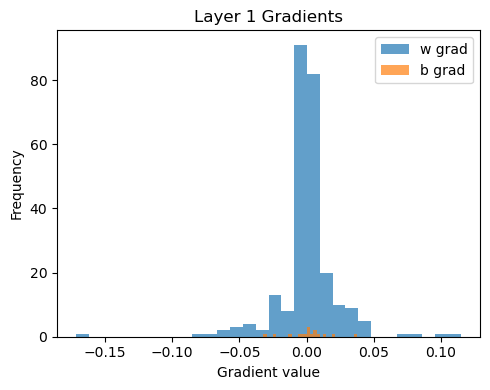


Training Aktivasi Layer Uji: sigmoid
Epoch 1/30
219/219 [------------------------------] - loss: 1.1714 - val_loss: 0.9287
Epoch 2/30
219/219 [------------------------------] - loss: 0.9045 - val_loss: 0.8577
Epoch 3/30
219/219 [------------------------------] - loss: 0.8412 - val_loss: 0.8115
Epoch 4/30
219/219 [------------------------------] - loss: 0.7975 - val_loss: 0.7787
Epoch 5/30
219/219 [------------------------------] - loss: 0.7655 - val_loss: 0.7545
Epoch 6/30
219/219 [------------------------------] - loss: 0.7421 - val_loss: 0.7366
Epoch 7/30
219/219 [------------------------------] - loss: 0.7236 - val_loss: 0.7225
Epoch 8/30
219/219 [------------------------------] - loss: 0.7091 - val_loss: 0.7113
Epoch 9/30
219/219 [------------------------------] - loss: 0.6975 - val_loss: 0.7021
Epoch 10/30
219/219 [------------------------------] - loss: 0.6876 - val_loss: 0.6945
Epoch 11/30
219/219 [------------------------------] - loss: 0.6795 - val_loss: 0.6884
Epoch 12/30
21

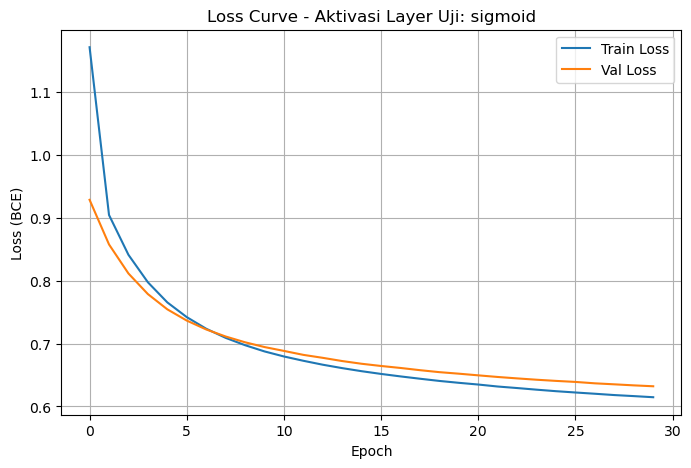


[Evaluasi Validation] Aktivasi sigmoid:
Accuracy: 0.6389
                precision    recall  f1-score   support

Not Placed (0)       0.57      0.38      0.45       594
    Placed (1)       0.67      0.81      0.73       907

      accuracy                           0.64      1501
     macro avg       0.62      0.59      0.59      1501
  weighted avg       0.63      0.64      0.62      1501


[Distribusi] Aktivasi sigmoid - Layer Uji


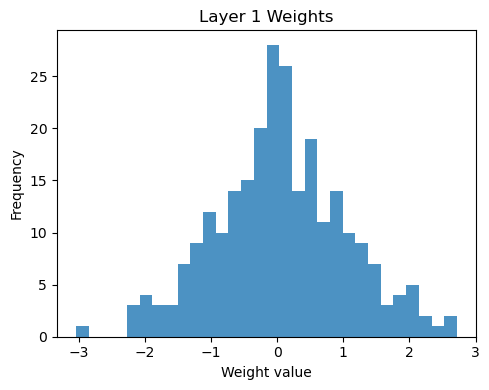

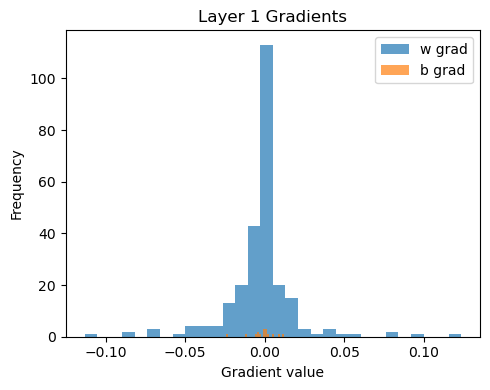


Training Aktivasi Layer Uji: tanh
Epoch 1/30
92/219 [------------>.................] - loss: nan645

c:\Users\Kinan\Documents\Kinan-Docs\Kuliah\Jurusan\semester6\ML\tubes1\Tubes1-ML-FFNN-G60\src\models\activations.py:39: RuntimeWarning: overflow encountered in exp
  e2 = np.exp(-x.data)
c:\Users\Kinan\Documents\Kinan-Docs\Kuliah\Jurusan\semester6\ML\tubes1\Tubes1-ML-FFNN-G60\src\models\activations.py:41: RuntimeWarning: invalid value encountered in divide
  v = (e1-e2)/(e1+e2)


219/219 [------------------------------] - loss: nan - val_loss: nan
Epoch 2/30
219/219 [------------------------------] - loss: nan - val_loss: nan
Epoch 3/30
219/219 [------------------------------] - loss: nan - val_loss: nan
Epoch 4/30
219/219 [------------------------------] - loss: nan - val_loss: nan
Epoch 5/30
219/219 [------------------------------] - loss: nan - val_loss: nan
Epoch 6/30
219/219 [------------------------------] - loss: nan - val_loss: nan
Epoch 7/30
219/219 [------------------------------] - loss: nan - val_loss: nan
Epoch 8/30
219/219 [------------------------------] - loss: nan - val_loss: nan
Epoch 9/30
219/219 [------------------------------] - loss: nan - val_loss: nan
Epoch 10/30
219/219 [------------------------------] - loss: nan - val_loss: nan
Epoch 11/30
219/219 [------------------------------] - loss: nan - val_loss: nan
Epoch 12/30
219/219 [------------------------------] - loss: nan - val_loss: nan
Epoch 13/30
219/219 [---------------------------

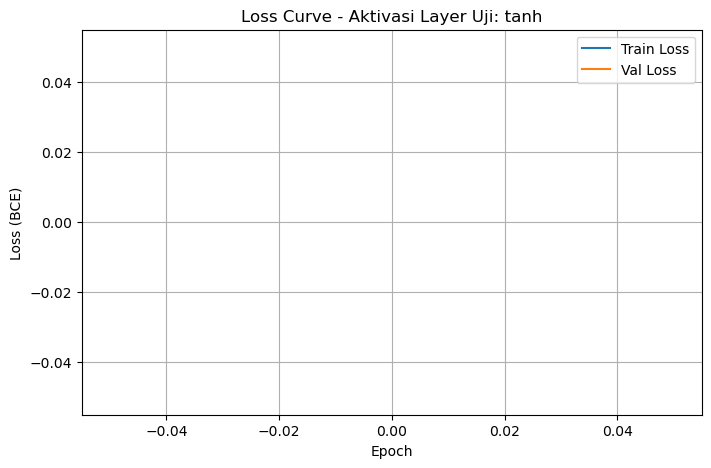


[Evaluasi Validation] Aktivasi tanh:
Accuracy: 0.3957
                precision    recall  f1-score   support

Not Placed (0)       0.40      1.00      0.57       594
    Placed (1)       0.00      0.00      0.00       907

      accuracy                           0.40      1501
     macro avg       0.20      0.50      0.28      1501
  weighted avg       0.16      0.40      0.22      1501


[Distribusi] Aktivasi tanh - Layer Uji


c:\Users\Kinan\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:6763: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
c:\Users\Kinan\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:6764: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

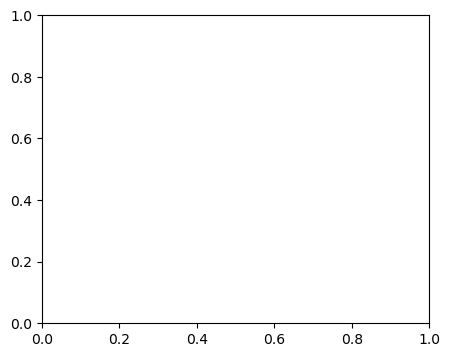

In [35]:
# Base arsitektur: Input -> Hidden1 -> Hidden2 (Layer Uji) -> Hidden3 -> Output
config_act = [nin, 16, 16, 16, 1]

activation_functions = ['linear', 'relu', 'sigmoid', 'tanh']
models_act = {}

for act in activation_functions:
    print(f"\nTraining Aktivasi Layer Uji: {act}")
    acts = ['relu', act, 'relu', 'sigmoid']
    
    model_a = FFNN(layers_config=config_act, activations=acts, loss_function='bce', random_state=RANDOM_STATE)
    history_a = model_a.fit(X_train, y_train, X_val, y_val, solver='sgd', lr=0.001, epochs=30, batch_size=32, verbose=1)
    
    models_act[act] = model_a
    plot_loss_curve(history_a, title=f"Loss Curve - Aktivasi Layer Uji: {act}")
    print(f"\n[Evaluasi Validation] Aktivasi {act}:")
    evaluate_model(model_a, X_val, y_val)
    
    print(f"\n[Distribusi] Aktivasi {act} - Layer Uji")
    model_a.plot_weights_distribution(layer_indices=[1])
    model_a.plot_gradients_distribution(layer_indices=[1])

#### 3.1.3 Pengaruh learning rate.


Training Model Learning Rate: 0.1
Epoch 1/30
219/219 [------------------------------] - loss: 3.4506 - val_loss: 0.7320
Epoch 2/30
219/219 [------------------------------] - loss: 0.6129 - val_loss: 0.6201
Epoch 3/30
219/219 [------------------------------] - loss: 0.5545 - val_loss: 0.6172
Epoch 4/30
219/219 [------------------------------] - loss: 0.5391 - val_loss: 0.5621
Epoch 5/30
219/219 [------------------------------] - loss: 0.5277 - val_loss: 0.5629
Epoch 6/30
219/219 [------------------------------] - loss: 0.5202 - val_loss: 0.5586
Epoch 7/30
219/219 [------------------------------] - loss: 0.5164 - val_loss: 0.5596
Epoch 8/30
219/219 [------------------------------] - loss: 0.5091 - val_loss: 0.5629
Epoch 9/30
219/219 [------------------------------] - loss: 0.5065 - val_loss: 0.5837
Epoch 10/30
219/219 [------------------------------] - loss: 0.5007 - val_loss: 0.5618
Epoch 11/30
219/219 [------------------------------] - loss: 0.4986 - val_loss: 0.5639
Epoch 12/30
219/2

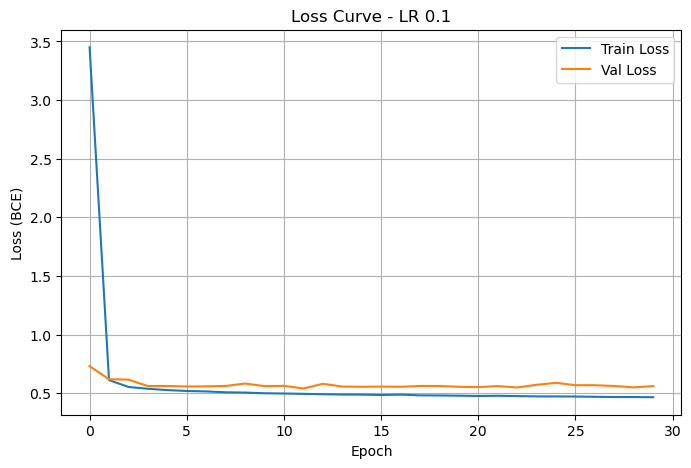


[Evaluasi Validation] LR 0.1:
Accuracy: 0.7182
                precision    recall  f1-score   support

Not Placed (0)       0.69      0.52      0.60       594
    Placed (1)       0.73      0.85      0.78       907

      accuracy                           0.72      1501
     macro avg       0.71      0.68      0.69      1501
  weighted avg       0.71      0.72      0.71      1501


[Distribusi Gradien] LR 0.1 - Semua Hidden Layer


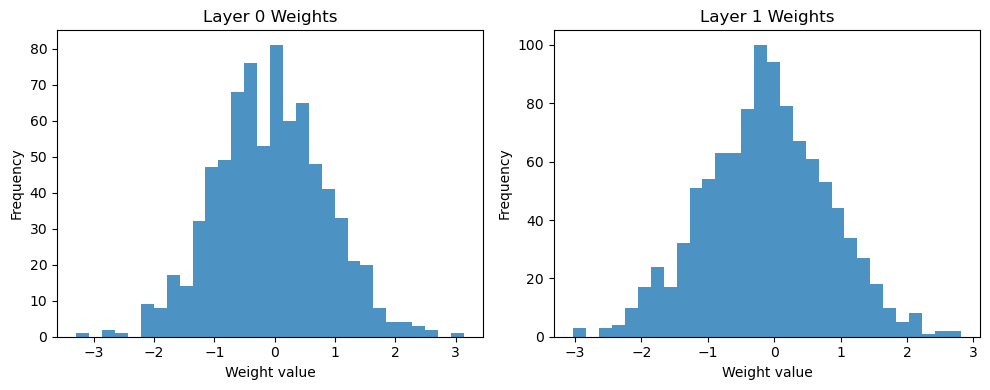

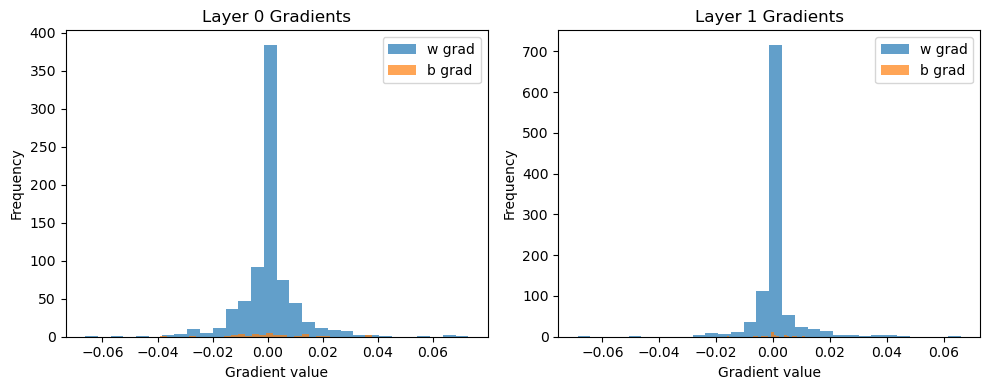


Training Model Learning Rate: 0.01
Epoch 1/30
219/219 [------------------------------] - loss: 3.6701 - val_loss: 2.2600
Epoch 2/30
219/219 [------------------------------] - loss: 1.6419 - val_loss: 1.5643
Epoch 3/30
219/219 [------------------------------] - loss: 1.1596 - val_loss: 1.2229
Epoch 4/30
219/219 [------------------------------] - loss: 0.9775 - val_loss: 0.8190
Epoch 5/30
219/219 [------------------------------] - loss: 0.8498 - val_loss: 0.6816
Epoch 6/30
219/219 [------------------------------] - loss: 0.7821 - val_loss: 1.2817
Epoch 7/30
219/219 [------------------------------] - loss: 0.7212 - val_loss: 0.8591
Epoch 8/30
219/219 [------------------------------] - loss: 0.6859 - val_loss: 0.7870
Epoch 9/30
219/219 [------------------------------] - loss: 0.6672 - val_loss: 0.8262
Epoch 10/30
219/219 [------------------------------] - loss: 0.6180 - val_loss: 0.5844
Epoch 11/30
219/219 [------------------------------] - loss: 0.6281 - val_loss: 0.6236
Epoch 12/30
219/

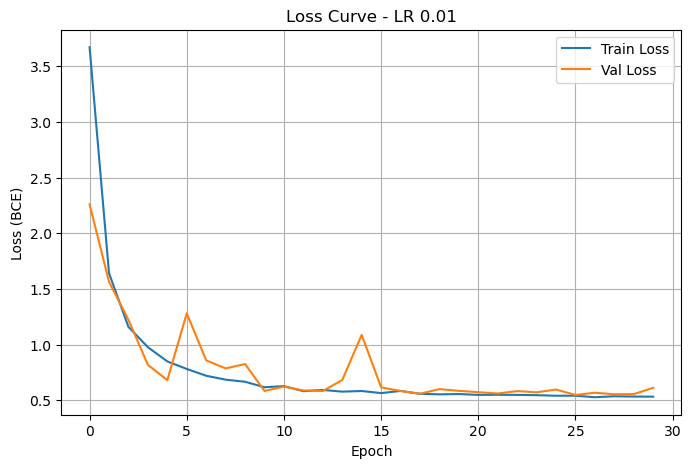


[Evaluasi Validation] LR 0.01:
Accuracy: 0.6935
                precision    recall  f1-score   support

Not Placed (0)       0.73      0.36      0.48       594
    Placed (1)       0.68      0.91      0.78       907

      accuracy                           0.69      1501
     macro avg       0.71      0.64      0.63      1501
  weighted avg       0.70      0.69      0.66      1501


[Distribusi Gradien] LR 0.01 - Semua Hidden Layer


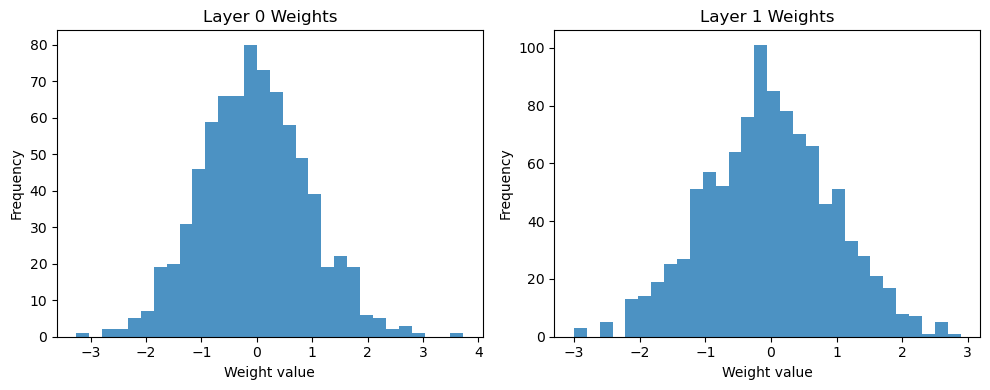

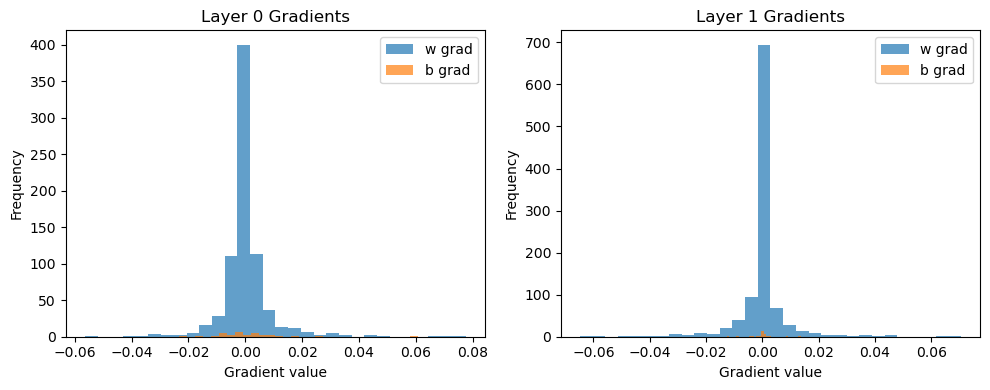


Training Model Learning Rate: 0.001
Epoch 1/30
219/219 [------------------------------] - loss: 7.3569 - val_loss: 5.7065
Epoch 2/30
219/219 [------------------------------] - loss: 4.6926 - val_loss: 4.4264
Epoch 3/30
219/219 [------------------------------] - loss: 3.7551 - val_loss: 3.7650
Epoch 4/30
219/219 [------------------------------] - loss: 3.2223 - val_loss: 3.2413
Epoch 5/30
219/219 [------------------------------] - loss: 2.8404 - val_loss: 2.9079
Epoch 6/30
219/219 [------------------------------] - loss: 2.5584 - val_loss: 2.6272
Epoch 7/30
219/219 [------------------------------] - loss: 2.3267 - val_loss: 2.4292
Epoch 8/30
219/219 [------------------------------] - loss: 2.1403 - val_loss: 2.2452
Epoch 9/30
219/219 [------------------------------] - loss: 1.9819 - val_loss: 2.0857
Epoch 10/30
219/219 [------------------------------] - loss: 1.8457 - val_loss: 1.9439
Epoch 11/30
219/219 [------------------------------] - loss: 1.7301 - val_loss: 1.8581
Epoch 12/30
219

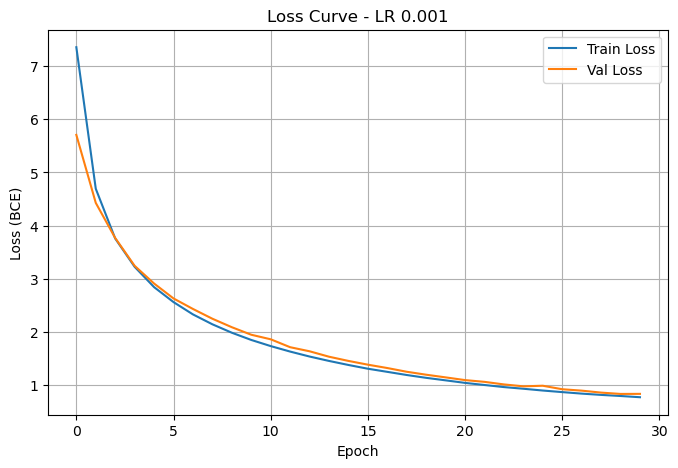


[Evaluasi Validation] LR 0.001:
Accuracy: 0.6875
                precision    recall  f1-score   support

Not Placed (0)       0.63      0.51      0.56       594
    Placed (1)       0.71      0.81      0.76       907

      accuracy                           0.69      1501
     macro avg       0.67      0.66      0.66      1501
  weighted avg       0.68      0.69      0.68      1501


[Distribusi Gradien] LR 0.001 - Semua Hidden Layer


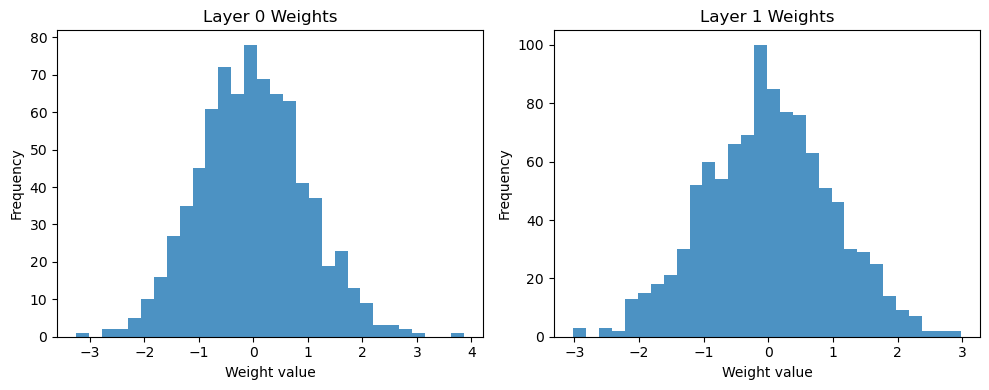

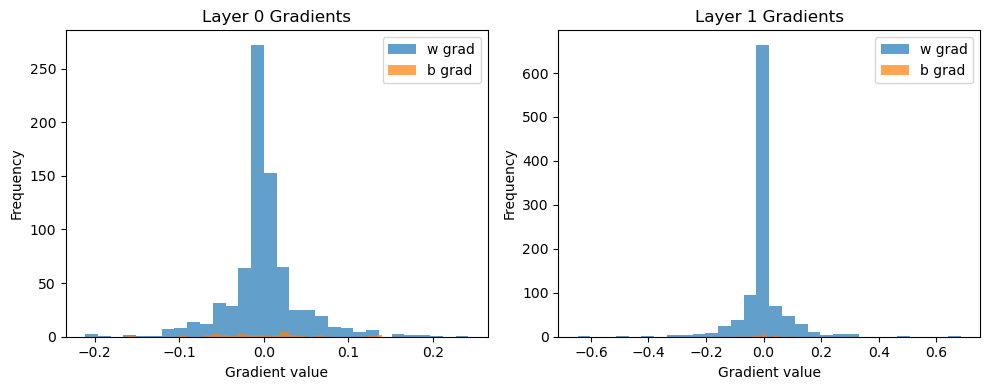

In [36]:
learning_rates = [0.1, 0.01, 0.001]
models_lr = {}

for lr in learning_rates:
    print(f"\nTraining Model Learning Rate: {lr}")
    config = [nin, 32, 32, 1]
    acts = ['relu', 'relu', 'sigmoid']
    
    model_lr = FFNN(layers_config=config, activations=acts, loss_function='bce', random_state=RANDOM_STATE)
    history_lr = model_lr.fit(X_train, y_train, X_val, y_val, solver='sgd', lr=lr, epochs=30, batch_size=32, verbose=1)
    
    models_lr[lr] = model_lr
    plot_loss_curve(history_lr, title=f"Loss Curve - LR {lr}")
    print(f"\n[Evaluasi Validation] LR {lr}:")
    evaluate_model(model_lr, X_val, y_val)
    
    print(f"\n[Distribusi Gradien] LR {lr} - Semua Hidden Layer")
    model_lr.plot_weights_distribution(layer_indices=[0, 1])
    model_lr.plot_gradients_distribution(layer_indices=[0, 1])

### 3.2 Pengaruh Regularisasi.



Training Model: Tanpa Regularisasi
Epoch 1/30
219/219 [------------------------------] - loss: 7.8337 - val_loss: 6.4192
Epoch 2/30
219/219 [------------------------------] - loss: 5.4049 - val_loss: 5.6733
Epoch 3/30
219/219 [------------------------------] - loss: 3.6984 - val_loss: 2.8773
Epoch 4/30
219/219 [------------------------------] - loss: 2.8377 - val_loss: 3.5560
Epoch 5/30
219/219 [------------------------------] - loss: 2.1430 - val_loss: 2.8315
Epoch 6/30
219/219 [------------------------------] - loss: 1.7468 - val_loss: 3.9115
Epoch 7/30
219/219 [------------------------------] - loss: 1.3982 - val_loss: 3.9878
Epoch 8/30
219/219 [------------------------------] - loss: 1.2833 - val_loss: 1.1819
Epoch 9/30
219/219 [------------------------------] - loss: 1.1090 - val_loss: 1.8479
Epoch 10/30
219/219 [------------------------------] - loss: 1.0842 - val_loss: 1.1794
Epoch 11/30
219/219 [------------------------------] - loss: 0.9280 - val_loss: 0.7991
Epoch 12/30
219/

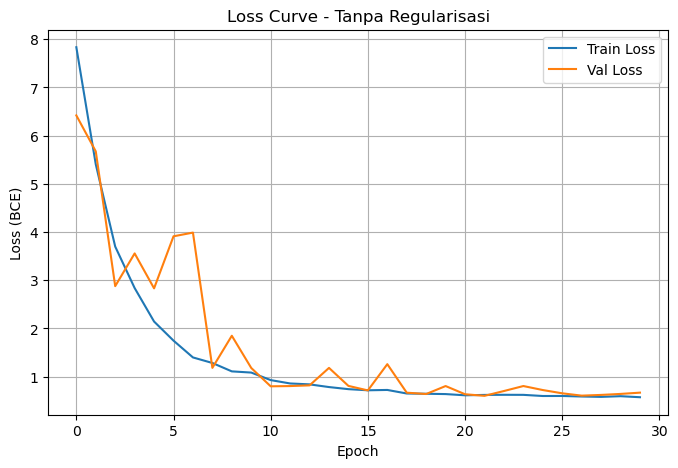


[Evaluasi Validation] Tanpa Regularisasi:
Accuracy: 0.7009
                precision    recall  f1-score   support

Not Placed (0)       0.70      0.42      0.53       594
    Placed (1)       0.70      0.88      0.78       907

      accuracy                           0.70      1501
     macro avg       0.70      0.65      0.65      1501
  weighted avg       0.70      0.70      0.68      1501


[Distribusi Bobot & Gradien] Tanpa Regularisasi


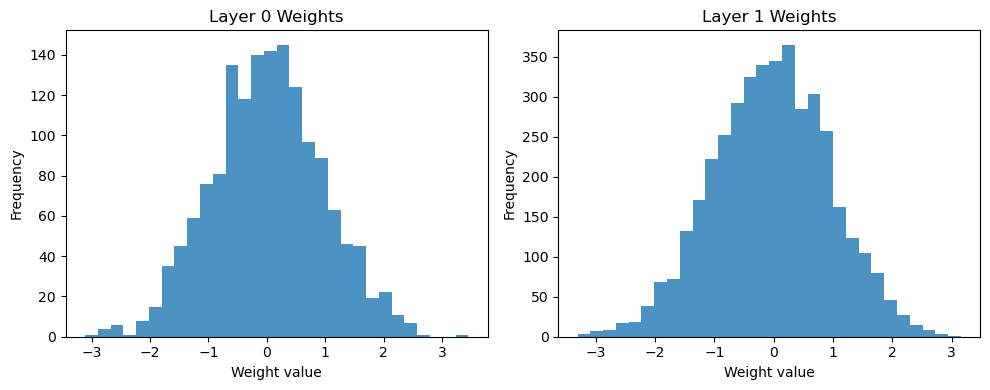

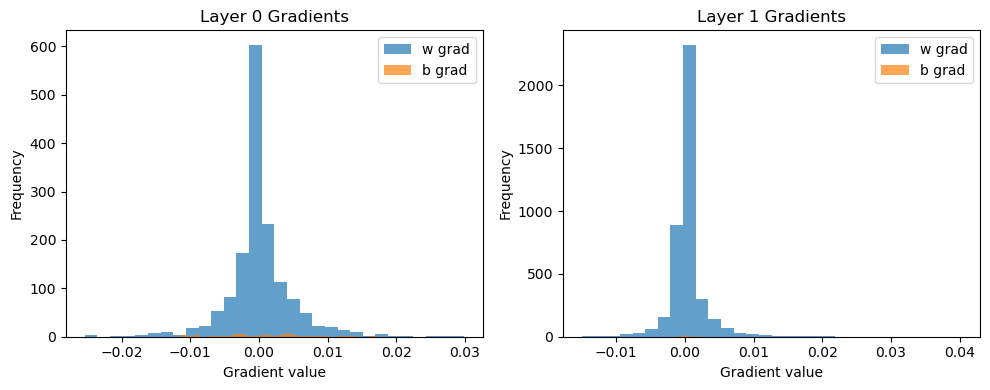


Training Model: L1 Regularization
Epoch 1/30
219/219 [------------------------------] - loss: 12.3681 - val_loss: 10.8117
Epoch 2/30
219/219 [------------------------------] - loss: 9.94732 - val_loss: 10.1605
Epoch 3/30
219/219 [------------------------------] - loss: 8.2011 - val_loss: 7.3452
Epoch 4/30
219/219 [------------------------------] - loss: 7.2102 - val_loss: 7.7315
Epoch 5/30
219/219 [------------------------------] - loss: 6.5018 - val_loss: 7.0990
Epoch 6/30
219/219 [------------------------------] - loss: 6.0906 - val_loss: 7.9358
Epoch 7/30
219/219 [------------------------------] - loss: 5.7172 - val_loss: 8.1343
Epoch 8/30
219/219 [------------------------------] - loss: 5.5947 - val_loss: 5.4352
Epoch 9/30
219/219 [------------------------------] - loss: 5.4090 - val_loss: 5.9341
Epoch 10/30
219/219 [------------------------------] - loss: 5.3599 - val_loss: 5.5557
Epoch 11/30
219/219 [------------------------------] - loss: 5.1907 - val_loss: 5.0739
Epoch 12/30
2

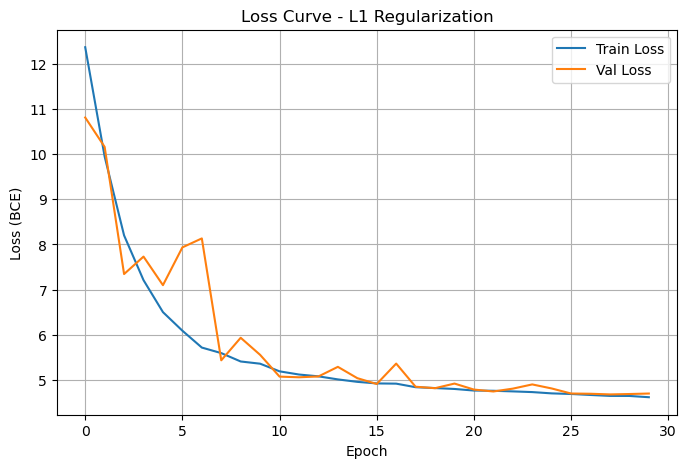


[Evaluasi Validation] L1 Regularization:
Accuracy: 0.7109
                precision    recall  f1-score   support

Not Placed (0)       0.71      0.45      0.55       594
    Placed (1)       0.71      0.88      0.79       907

      accuracy                           0.71      1501
     macro avg       0.71      0.67      0.67      1501
  weighted avg       0.71      0.71      0.69      1501


[Distribusi Bobot & Gradien] L1 Regularization


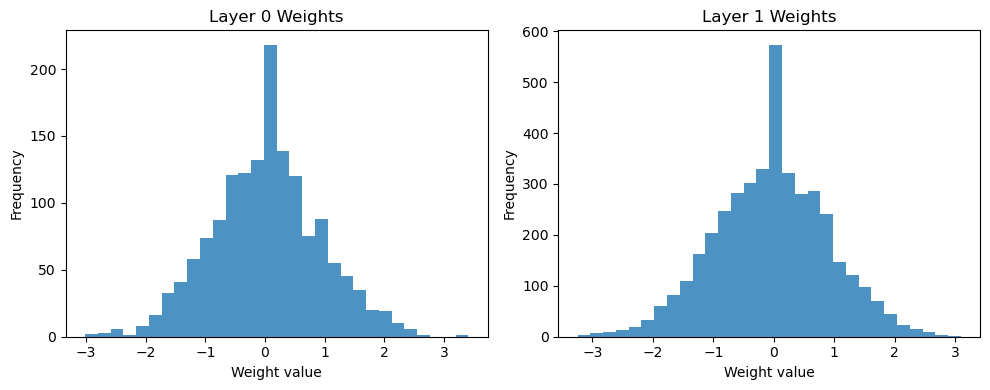

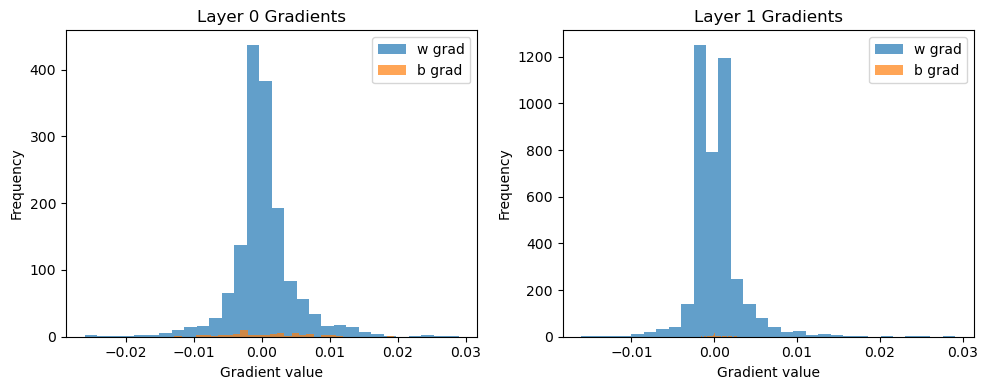


Training Model: L2 Regularization
Epoch 1/30
219/219 [------------------------------] - loss: 13.4532 - val_loss: 11.9212
Epoch 2/30
219/219 [------------------------------] - loss: 10.9391 - val_loss: 11.0834
Epoch 3/30
219/219 [------------------------------] - loss: 9.0635 - val_loss: 8.2276
Epoch 4/30
219/219 [------------------------------] - loss: 8.0574 - val_loss: 8.6459
Epoch 5/30
219/219 [------------------------------] - loss: 7.3075 - val_loss: 7.6814
Epoch 6/30
219/219 [------------------------------] - loss: 6.8489 - val_loss: 8.5330
Epoch 7/30
219/219 [------------------------------] - loss: 6.4624 - val_loss: 8.5686
Epoch 8/30
219/219 [------------------------------] - loss: 6.2962 - val_loss: 6.1339
Epoch 9/30
219/219 [------------------------------] - loss: 6.0718 - val_loss: 6.5718
Epoch 10/30
219/219 [------------------------------] - loss: 5.9966 - val_loss: 6.1617
Epoch 11/30
219/219 [------------------------------] - loss: 5.8019 - val_loss: 5.6966
Epoch 12/30
2

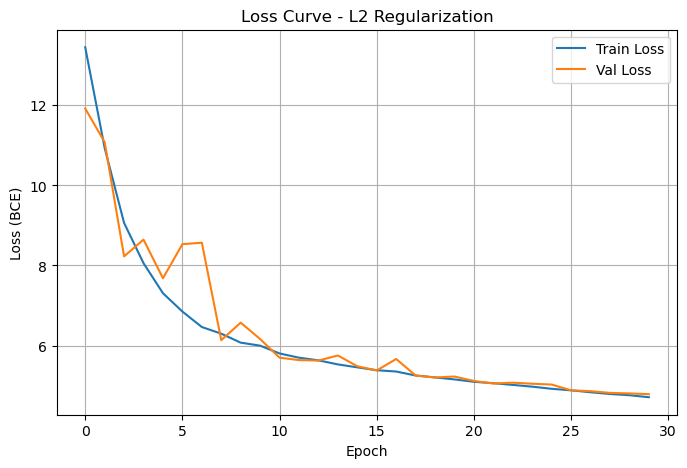


[Evaluasi Validation] L2 Regularization:
Accuracy: 0.7095
                precision    recall  f1-score   support

Not Placed (0)       0.72      0.43      0.54       594
    Placed (1)       0.71      0.89      0.79       907

      accuracy                           0.71      1501
     macro avg       0.71      0.66      0.66      1501
  weighted avg       0.71      0.71      0.69      1501


[Distribusi Bobot & Gradien] L2 Regularization


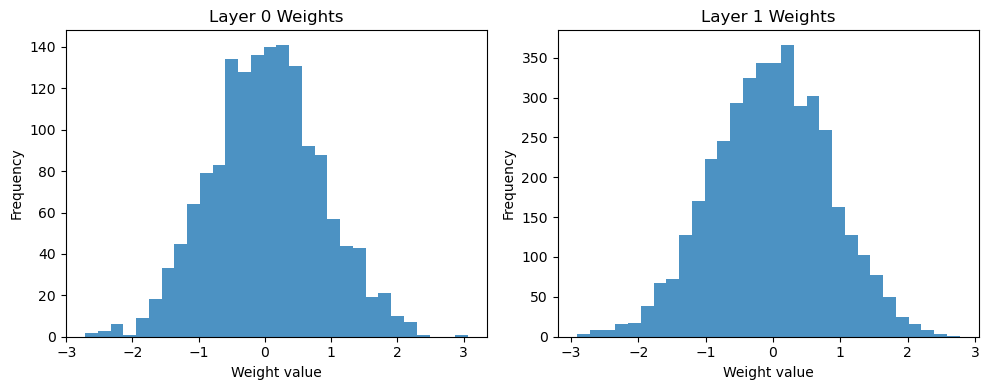

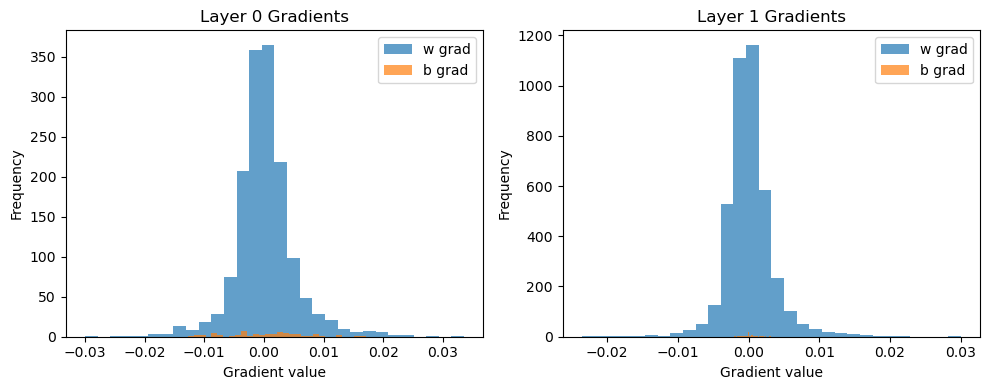

In [37]:
reg_variations = {
    "Tanpa Regularisasi": {"l1_lambda": 0.0, "l2_lambda": 0.0},
    "L1 Regularization": {"l1_lambda": 0.001, "l2_lambda": 0.0},
    "L2 Regularization": {"l1_lambda": 0.0, "l2_lambda": 0.001}
}
models_reg = {}

for name, params in reg_variations.items():
    print(f"\nTraining Model: {name}")
    config = [nin, 64, 64, 1] # 64 agar terlihat efek overfit/reg
    acts = ['relu', 'relu', 'sigmoid']
    
    model_r = FFNN(layers_config=config, activations=acts, loss_function='bce', random_state=RANDOM_STATE)
    history_r = model_r.fit(X_train, y_train, X_val, y_val, solver='sgd', lr=0.01, epochs=30, batch_size=32, l1_lambda=params["l1_lambda"], l2_lambda=params["l2_lambda"], verbose=1)
    
    models_reg[name] = model_r
    plot_loss_curve(history_r, title=f"Loss Curve - {name}")
    print(f"\n[Evaluasi Validation] {name}:")
    evaluate_model(model_r, X_val, y_val)
    
    print(f"\n[Distribusi Bobot & Gradien] {name}")
    model_r.plot_weights_distribution(layer_indices=[0, 1])
    model_r.plot_gradients_distribution(layer_indices=[0, 1])

### 3.3 Uji Perbandingan.

In [39]:
print("\nUji Perbandingan: Custom FFNN vs Sklearn MLP")

config_custom = [nin, 32, 32, 1]
acts_custom = ['relu', 'relu', 'sigmoid']
model_custom = FFNN(layers_config=config_custom, activations=acts_custom, loss_function='bce', random_state=RANDOM_STATE)
model_custom.fit(X_train, y_train, X_val, y_val, solver='sgd', lr=0.01, epochs=100, batch_size=32, verbose=0)

print("\n[Hasil Akhir] Custom FFNN di Data TEST:")
evaluate_model(model_custom, X_test, y_test)

model_sklearn = MLPClassifier(
    hidden_layer_sizes=(32, 32),
    activation='relu',
    solver='sgd',
    learning_rate_init=0.01,
    batch_size=32,
    max_iter=100,
    random_state=RANDOM_STATE,
    alpha=0.0
)
model_sklearn.fit(X_train, y_train.ravel())
preds_sklearn = model_sklearn.predict(X_test)

print("\n[Hasil Akhir] Sklearn MLPClassifier di Data TEST:")
print(f"Accuracy: {accuracy_score(y_test.ravel(), preds_sklearn):.4f}")
print(classification_report(y_test.ravel(), preds_sklearn, target_names=['Not Placed (0)', 'Placed (1)'], zero_division=0))


Uji Perbandingan: Custom FFNN vs Sklearn MLP

[Hasil Akhir] Custom FFNN di Data TEST:
Accuracy: 0.7520
                precision    recall  f1-score   support

Not Placed (0)       0.73      0.58      0.65       589
    Placed (1)       0.76      0.86      0.81       911

      accuracy                           0.75      1500
     macro avg       0.75      0.72      0.73      1500
  weighted avg       0.75      0.75      0.75      1500


[Hasil Akhir] Sklearn MLPClassifier di Data TEST:
Accuracy: 0.7273
                precision    recall  f1-score   support

Not Placed (0)       0.68      0.58      0.63       589
    Placed (1)       0.75      0.82      0.79       911

      accuracy                           0.73      1500
     macro avg       0.72      0.70      0.71      1500
  weighted avg       0.72      0.73      0.72      1500



c:\Users\Kinan\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


**Kesimpulan Perbandingan:**  
